<a href="https://colab.research.google.com/github/Riteshpaul3/Brain-Tumor-Detection-Python-/blob/main/Grad_CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

# Define constants
image_size = 150
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
X_data = []
Y_data = []

# Use generator-style approach to avoid loading all at once
def load_images_in_batches(base_path, labels, image_size, max_images_per_class=500):
    X = []
    Y = []
    for label in labels:
        count = 0
        for folder in ['Training', 'Testing']:
            folder_path = os.path.join(base_path, folder, label)
            files = os.listdir(folder_path)
            for file in files:
                if count >= max_images_per_class:
                    break
                img_path = os.path.join(folder_path, file)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (image_size, image_size))
                    X.append(img / 255.0)  # Normalize on the fly
                    Y.append(labels.index(label))
                    count += 1
    return np.array(X, dtype=np.float32), tf.keras.utils.to_categorical(Y, num_classes=len(labels))

# Path to your dataset
base_path = '/content/drive/MyDrive/Final Year Project'

# Load limited number of images per class to avoid RAM crash
X_data, Y_data = load_images_in_batches(base_path, labels, image_size, max_images_per_class=500)


In [ ]:
X_data, Y_data = shuffle(X_data, Y_data, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.1, random_state=42)

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3, 3), activation='relu', name='last_conv'))  # Name this for Grad-CAM
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,447,044 (16.96 MB)

 Trainable params: 4,447,044 (16.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 314s 6s/step - accuracy: 0.3247 - loss: 1.3322 - val_accuracy: 0.4389 - val_loss: 1.0776
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 319s 6s/step - accuracy: 0.4258 - loss: 1.1346 - val_accuracy: 0.3944 - val_loss: 1.1765
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 312s 6s/step - accuracy: 0.5164 - loss: 1.0302 - val_accuracy: 0.7722 - val_loss: 0.5759
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 321s 6s/step - accuracy: 0.7652 - loss: 0.6351 - val_accuracy: 0.7778 - val_loss: 0.5583
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 325s 6s/step - accuracy: 0.8128 - loss: 0.4724 - val_accuracy: 0.8778 - val_loss: 0.3505
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 319s 6s/step - accuracy: 0.8457 - loss: 0.4038 - val_accuracy: 0.8278 - val_loss: 0.4462
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 323s 6s/step - accuracy: 0.8666 - loss: 0.3070 - val_accuracy: 0.8389 - val_loss: 0.3861
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 323s 6s/step - accuracy: 0.8982 - loss: 0.2783 - val_accuracy: 0.8500 - v

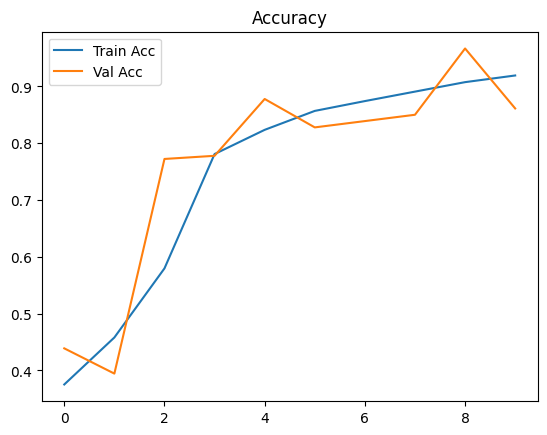

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

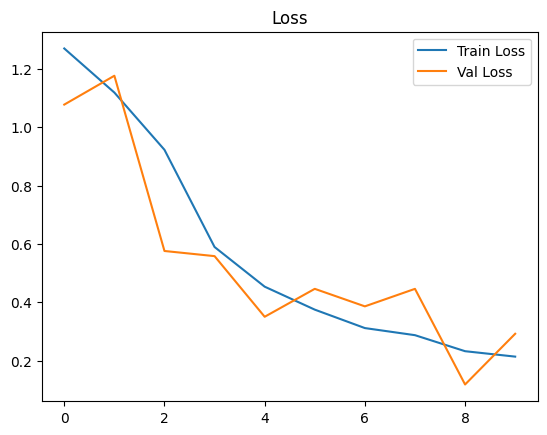

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap

In [ ]:
img_path = '/content/drive/MyDrive/Final Year Project/Testing/pituitary/Te-piTr_0009.jpg'
img = cv2.imread(img_path)
img = cv2.resize(img, (150, 150))
img_norm = img / 255.0
img_array = np.expand_dims(img_norm, axis=0)

In [ ]:
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction[0])
print("Predicted Tumor Type:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Tumor Type: pituitary


In [ ]:
# Example: Grad-CAM for MobileNetV2
import tensorflow as tf
import numpy as np

# Load model
model = tf.keras.applications.MobileNetV2(weights='imagenet')
img_size = (224, 224)

# Load and preprocess image
img = tf.keras.preprocessing.image.load_img('/content/drive/MyDrive/Final Year Project/Testing/pituitary/Te-piTr_0009.jpg', target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Call model to build it
_ = model(img_array)

# Check correct conv layer name
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last conv layer:", layer.name)
        break

# Assuming last conv layer is 'Conv_1'
heatmap = make_gradcam_heatmap(img_array, model, 'Conv_1')

Last conv layer: Conv_1


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_433']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [ ]:
from matplotlib import cm
import cv2
import numpy as np

# Convert PIL image to NumPy array if needed
img_np = np.array(img)  # img is the original PIL image

# Resize heatmap to match image size
heatmap_resized = cv2.resize(heatmap.numpy(), (img_np.shape[1], img_np.shape[0]))

# Convert to 0-255 and uint8
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Apply colormap
colormap = cm.get_cmap('jet')
heatmap_color = colormap(heatmap_uint8)  # shape: (H, W, 4)
heatmap_color = np.delete(heatmap_color, 3, axis=2)  # Remove alpha channel
heatmap_color = np.uint8(255 * heatmap_color)

# Superimpose heatmap on image
superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

<ipython-input-26-1439811f874d>:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet')


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

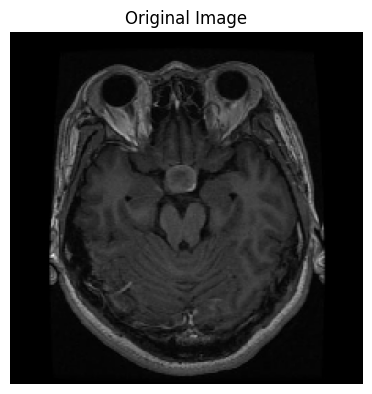

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Convert PIL image to NumPy array
img_np = np.array(img)

# Convert from BGR to RGB (only if using OpenCV image, but since this is from PIL, it's already RGB)
# If you *must* use cv2.cvtColor (e.g., if the image is in BGR), convert it like this:
# img_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)

# But since img from PIL is already RGB, you can skip cv2 and use directly:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_np)  # already RGB
plt.axis('off')

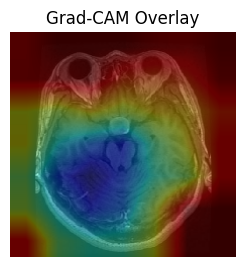

In [ ]:
plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()